# Import packages

In [1]:
import numpy as np # numerical computing
import matplotlib.pyplot as plt # plotting
import pandas as pd # data handling
from pathlib import Path # file handling
# the code below autoloads new changes (no restart of the kernel needed)
%reload_ext autoreload
%autoreload 2


# Data loading 

* when you download a dataset, always place it in `../data/` so you can easily open it via relative paths
* try loading it via pandas read options, you can check them out by running `pd.*read*?`
    * e.g. load csv-file `../data/trajectories.csv`: run `df = pd.read_csv("../data/trajectories.csv")`
    * now df is a DataFrame, that contains your data and you can work with it

In [2]:
df = pd.read_csv('../data/Experimental_school_N=8_recording_0.csv')
df = df.set_index('Time [frame]')
fps = 50 # frames per second of the recording
pixel_per_cm = 2745 / 100 
print(f'duration: {len(df)/fps / 60} minutes')

duration: 27.666 minutes


# Data preprocessing 

* some data needs to be preprocessed/cleaned
    * for example if it contains nans
    * useful commands are:
        * `df.head()` : shows first 5 rows 
        * `df.tail()` : shows last 5 rows
        * `df.isna().sum()` : shows for each column the number of nans it contains
        * `df.isna().sum()` : shows for each column the number of nans it contains
        * `df.dopna()`: drops rows if they contain nans (attention, full row is dropped even if only 1 column contains nan)

In [3]:
df.head()

,X_0 [px],Y_0 [px],X_1 [px],Y_1 [px],X_2 [px],Y_2 [px],X_3 [px],Y_3 [px],X_4 [px],Y_4 [px],X_5 [px],Y_5 [px],X_6 [px],Y_6 [px],X_7 [px],Y_7 [px]
Time [frame],,,,,,,,,,,,,,,,
0,2431.253416,707.080209,2447.125917,258.874706,2285.251384,289.218788,1925.473291,516.858528,2068.873710,419.259607,2405.578442,550.032925,2278.758304,492.824245,2387.982814,405.613957
1,2432.866500,704.649807,2449.314226,255.403852,2292.571458,285.124007,1932.066085,514.645174,2073.721632,415.816648,2408.169672,547.592644,2283.686098,488.437850,2392.908644,408.131965
2,2433.795514,703.487323,2451.205569,252.495904,2300.097833,280.814615,1938.732200,512.246003,2078.922806,411.998548,2410.886314,544.936072,2286.931728,485.434010,2395.684869,409.790455
3,2435.259248,701.747289,2453.049868,250.207487,2306.189052,277.658605,1945.621705,509.798421,2083.122091,409.025779,2412.070581,543.677139,2290.059723,482.822302,2400.035898,412.293820
4,2436.641438,699.995428,2454.084050,248.741132,2313.427728,273.732649,1951.903299,507.631338,2087.507880,406.213749,2414.539626,541.396742,2293.379355,479.989002,2403.774532,414.550717


In [4]:
df.tail()

,X_0 [px],Y_0 [px],X_1 [px],Y_1 [px],X_2 [px],Y_2 [px],X_3 [px],Y_3 [px],X_4 [px],Y_4 [px],X_5 [px],Y_5 [px],X_6 [px],Y_6 [px],X_7 [px],Y_7 [px]
Time [frame],,,,,,,,,,,,,,,,
82993,2015.292852,2646.141941,2277.413102,2624.228569,2370.962507,2637.330784,2091.455291,2598.315910,2151.497749,2676.615434,2395.772585,2722.716164,2271.793238,2759.904815,1992.328916,2707.291923
82994,2023.359808,2647.205351,2282.364543,2624.490839,2376.663239,2637.238390,2100.665184,2600.762539,2155.896030,2675.921692,2400.097402,2722.842179,2277.637499,2759.952514,2006.335074,2708.882232
82995,2031.079922,2648.329220,2286.681096,2624.770629,2381.098691,2637.291787,2107.621522,2602.625708,2159.448849,2675.367055,2404.337245,2723.024502,2282.262267,2759.860427,2020.356143,2709.418055
82996,2037.836401,2649.482298,2294.036579,2625.781322,2387.402998,2636.922034,2116.071119,2605.285543,2162.967932,2674.987636,2408.893013,2722.846154,2285.774833,2759.766014,2033.891876,2710.970047
82997,2044.639679,2650.592722,2301.612353,2628.296083,2390.813189,2636.627549,2123.302140,2607.576963,2165.800445,2674.347941,2413.536277,2722.723784,2289.598707,2759.701660,2046.863879,2712.790958


In [5]:
# ensure that no nans exist
df.isna().sum().sum()

np.int64(0)

In [6]:
# ensure the time is correctly sorted
df.index.diff().unique()

Index([nan, 1.0], dtype='float64', name='Time [frame]')

# Data analysis 
* after the data is cleaned you can start your analysis
* useful commands:
    * `df.mean()`, `df.std()`, `df.min()`, `df.max()`: some basic stats
    * `df.describe()`: the above stats and more in one command
    * `df.plot()`: plot all columns (using index as x-axis)
    * `df.hist()`: 

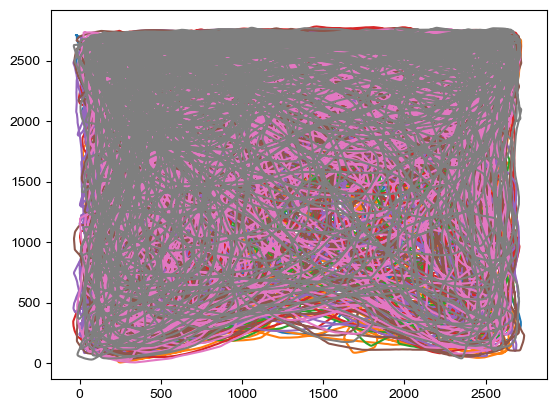

In [7]:
for i in range(8):
    plt.plot(df[f'X_{i} [px]'], df[f'Y_{i} [px]'])

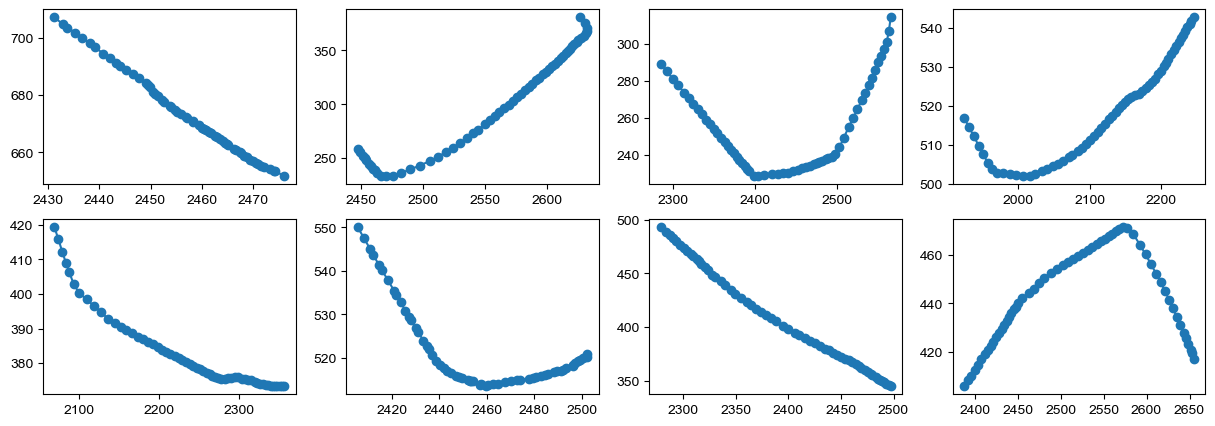

In [8]:
f, axs = plt.subplots(2, 4, figsize=(15, 5))
axs = axs.flatten()
df_ = df.head(60)
for i in range(8):
    axs[i].plot(df_[f'X_{i} [px]'], df_[f'Y_{i} [px]'], marker='o')

## Force map, relative position

In [9]:
df_v = df.diff()
df_a = df_v.diff()

In [10]:
NNdist = []
accel = []
for t, row in df.iterrows():
    for i in range(0, 8):
        x, y = row[f'X_{i} [px]'], row[f'Y_{i} [px]']
        NNdist_min = np.inf
        for j in range(0, 8):
            if i == j:
                continue
            x_other, y_other = row[f'X_{j} [px]'], row[f'Y_{j} [px]']
            dist = np.sqrt( (x-x_other)**2 + (y-y_other)**2 )
            NNdist_min = min(NNdist_min, dist)
        NNdist.append(NNdist_min)
        a = np.array(
            [df_a[f'X_{i} [px]'][t], df_a[f'Y_{i} [px]'][t]]
            )
        accel.append(np.sqrt(a[0]**2 + a[1]**2))

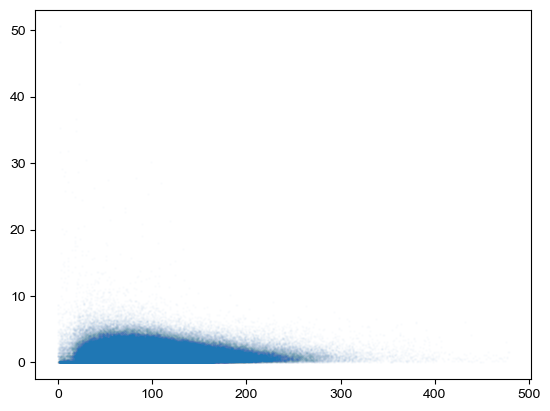

In [11]:
d = NNdist[2*8:]
a = accel[2*8:]
plt.scatter(d, a, alpha=0.01, s=1)

In [12]:
df_out = pd.DataFrame(data=np.array([d, a]).T,
                      columns=['NN_dist', 'a'])
df_out['quantile'] = pd.cut(df_out['NN_dist'], 40)
df_out = df_out.groupby('quantile').mean()

[Text(0.5, 0, 'NN_dist [cm]'), Text(0, 0.5, 'force [cm/s^2]'), (0.0, 11.0)]

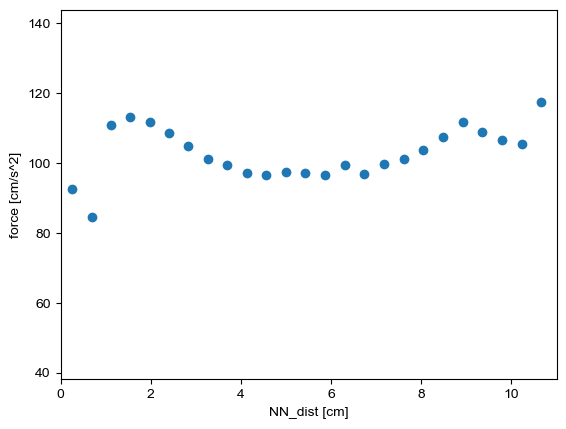

In [13]:
f, ax = plt.subplots()
ax.scatter(df_out['NN_dist']/pixel_per_cm, df_out['a']/pixel_per_cm*fps**2)
ax.set(xlabel='NN_dist [cm]', ylabel='force [cm/s^2]', xlim=[0, 11])


## real Force Map

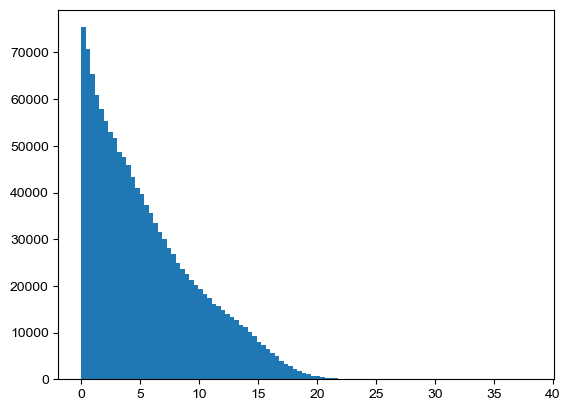

In [14]:
_ = plt.hist(df_v.dropna().abs().values.flatten(), bins=100)

In [15]:
# this is for real force map
diff_pos_para = []
diff_pos_perp = []
accel_para = []
accel_perp = []
for t, row in df.iterrows():
    for i in range(0, 8):
        x, y = row[f'X_{i} [px]'], row[f'Y_{i} [px]']
        NNdist_min = np.inf
        for j in range(0, 8):
            if i == j:
                continue
            x_other, y_other = row[f'X_{j} [px]'], row[f'Y_{j} [px]']
            dist = np.sqrt( (x-x_other)**2 + (y-y_other)**2 )
            if dist < NNdist_min:
                j_nn = j
                NNdist_min = dist
        a = np.array(
            [df_a[f'X_{i} [px]'][t], df_a[f'Y_{i} [px]'][t]]
            )
        # this is for real force map:
        v = np.array(
            [df_v[f'X_{i} [px]'][t], df_v[f'Y_{i} [px]'][t]]
            )
        u = v / np.sqrt(np.sum(v**2))
        u_perp = np.array([u[1], -u[0]])
        # output parallel and perp. acc. component
        accel_para.append(np.dot(a, u))
        accel_perp.append(np.dot(a, u_perp))
        # output parallel and perp rel position
        x_nn, y_nn = row[f'X_{j_nn} [px]'], row[f'Y_{j_nn} [px]']
        diff_pos = np.array([x - x_nn, y - y_nn])
        diff_pos_para.append(np.dot(diff_pos, u))
        diff_pos_perp.append(np.dot(diff_pos, u_perp))


/var/folders/f2/4l2m198x30zfsfr7br5dwp7h0000gn/T/ipykernel_42944/669526134.py:25: RuntimeWarning: invalid value encountered in divide
  u = v / np.sqrt(np.sum(v**2))


In [16]:
df_out = pd.DataFrame(data=np.array([diff_pos_para, diff_pos_perp, accel_para, accel_perp]).T,
                      columns=['dp_para', 'dp_perp', 'a_para', 'a_perp'])
df_out['quantile_para'] = pd.cut(df_out['dp_para'], 150)
df_out['quantile_perp'] = pd.cut(df_out['dp_perp'], 150)
df_out = df_out.groupby(['quantile_para', 'quantile_perp']).mean()
df_out['a_para_perp'] = np.sqrt(df_out['a_para']**2 + df_out['a_perp']**2)

<Axes: >

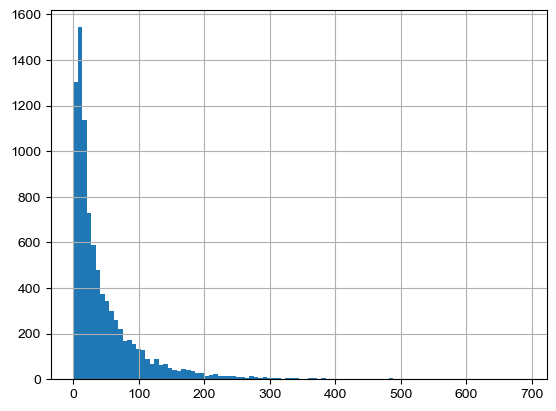

In [17]:
(df_out['a_para_perp']/pixel_per_cm*fps**2).hist(bins=100)

In [18]:
cmap = plt.get_cmap('viridis')

[(-11.0, 11.0), (-11.0, 11.0), None]

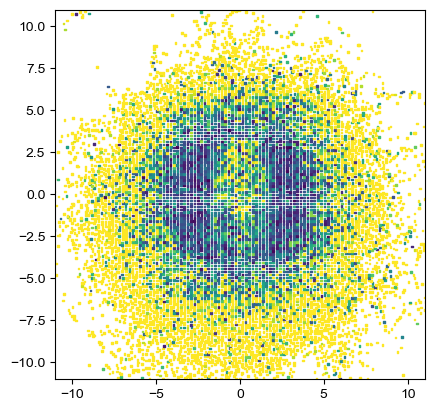

In [19]:
f, ax = plt.subplots()
c = df_out['a_para_perp'] / df_out['a_para_perp'].max() * 30
c = cmap(c)
ax.scatter(df_out['dp_perp']/pixel_per_cm,
            df_out['dp_para']/pixel_per_cm, s=1.5, marker='s', color=c)
lims = [-11,11]
ax.set(xlim=lims, ylim=lims, aspect='equal')